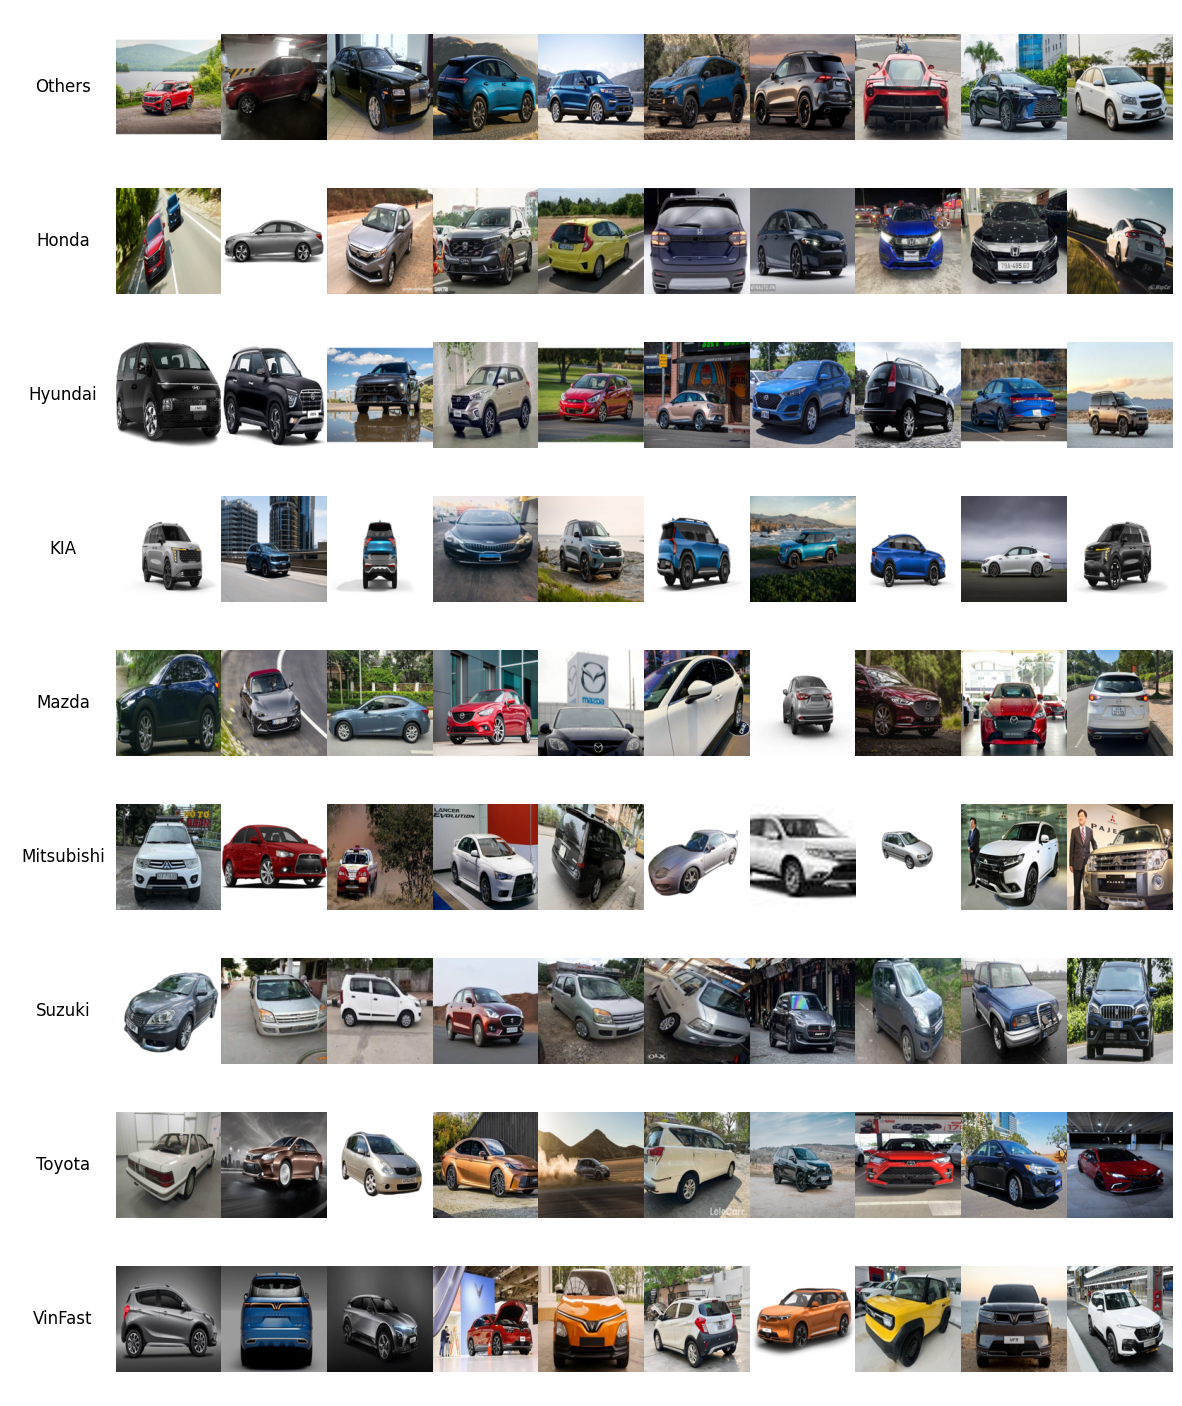

In [3]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

NumImgsPerRow = 10
ImgHeight = 150
ImgWidth = 150

def display_images_grid_with_labels(csv_path, data_path, label_map):
    """
    Hiển thị ảnh từ tệp .csv theo từng CategoryID dưới dạng lưới với nhãn bên trái.
    """
    # Đọc dữ liệu từ tệp CSV
    df = pd.read_csv(csv_path)

    # Nhóm ảnh theo CategoryID
    grouped = df.groupby("CategoryID")

    # Tạo subplots mà không có khoảng cách giữa các ảnh
    fig, axes = plt.subplots(len(grouped), NumImgsPerRow + 1, figsize=(15, len(grouped) * 2))
    plt.subplots_adjust(hspace=0, wspace=0)  # Loại bỏ khoảng cách giữa các ảnh
    for ax in axes.flatten():
        ax.axis("off")  # Tắt các trục của tất cả các ảnh

    for row_idx, (category_id, group) in enumerate(grouped):
        # Lấy ngẫu nhiên NumImgsPerRow ảnh
        images = group["ImageFullPath"].tolist()
        random_images = random.sample(images, min(len(images), NumImgsPerRow))

        # Thêm nhãn ở cột đầu tiên
        ax_label = axes[row_idx, 0] if len(grouped) > 1 else axes[0]
        ax_label.text(0.5, 0.5, label_map.get(category_id, f"ID {category_id}"), fontsize=12,
                      verticalalignment="center", horizontalalignment="center", transform=ax_label.transAxes)

        # Hiển thị ảnh trên hàng tương ứng
        for col_idx in range(NumImgsPerRow):
            ax = axes[row_idx, col_idx + 1] if len(grouped) > 1 else axes[col_idx + 1]
            if col_idx < len(random_images):
                full_image_path = os.path.join(data_path, random_images[col_idx])
                try:
                    img = Image.open(full_image_path).resize((ImgWidth, ImgHeight))
                    ax.imshow(img)
                except Exception as e:
                    print(f"Lỗi khi mở ảnh {full_image_path}: {e}")

    plt.show()

# Đường dẫn đến tập tin CSV và thư mục dữ liệu
csv_path = '/kaggle/input/split-data-car/CarDataset-Splits-1-Train.csv'  # Thay đổi đường dẫn phù hợp
data_path = '/kaggle/input/cs114-all-cars'

# Bản đồ CategoryID sang tên nhãn
label_map = {
    0 :"Others",
    1: "Honda",
    2: "Hyundai",
    3: "KIA",
    4: "Mazda",
    5: "Mitsubishi",
    6: "Suzuki",
    7: "Toyota",
    8: "VinFast"
}

# Hiển thị ảnh từ tập tin CSV
display_images_grid_with_labels(csv_path, data_path, label_map)